In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [3]:
from google.colab import files
uploaded = files.upload()

Saving True.csv to True.csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv


In [6]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

fake['label'] = 1   # Fake
real['label'] = 0   # Real


df = pd.concat([fake, real])


df = df[['title', 'text', 'label']]


df['text'] = df['title'] + " " + df['text']


df = df[['text', 'label']]

print(df.head())

                                                text  label
0   Donald Trump Sends Out Embarrassing New Year’...      1
1   Drunk Bragging Trump Staffer Started Russian ...      1
2   Sheriff David Clarke Becomes An Internet Joke...      1
3   Trump Is So Obsessed He Even Has Obama’s Name...      1
4   Pope Francis Just Called Out Donald Trump Dur...      1


In [7]:
print("Dataset shape:", df.shape)
print(df['label'].value_counts())

Dataset shape: (23981, 2)
label
1    23481
0      500
Name: count, dtype: int64


In [8]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['text']).toarray()
y = df['label']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9959 - loss: 0.0226 - val_accuracy: 1.0000 - val_loss: 8.0981e-05
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 1.0000 - loss: 3.1286e-05 - val_accuracy: 1.0000 - val_loss: 1.8952e-05
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 1.0000 - loss: 8.8304e-06 - val_accuracy: 1.0000 - val_loss: 8.3092e-06
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 1.0000 - loss: 3.8843e-06 - val_accuracy: 1.0000 - val_loss: 4.5616e-06
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 1.0000 - loss: 2.0401e-06 - val_accuracy: 1.0000 - val_loss: 2.8062e-06
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 1.0000 - loss: 1.1753e-06 - val_accuracy: 1.0000 - val_loss: 1.8372e-06
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 1.0000 - loss: 7.1454e-07 - val_accuracy: 1.0000 - val_loss: 1.2707e-06
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 1

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Accuracy:", accuracy)

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 4.9274e-07
Final Accuracy: 1.0


In [15]:
def predict_news(text):
    text_vector = vectorizer.transform([text]).toarray()
    prediction = model.predict(text_vector)

    if prediction > 0.5:
        return "Fake News"
    else:
        return "Real News"


print(predict_news("Scientists discover new species in the Amazon"))
print(predict_news("Aliens secretly control the government."))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Real News
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Fake News


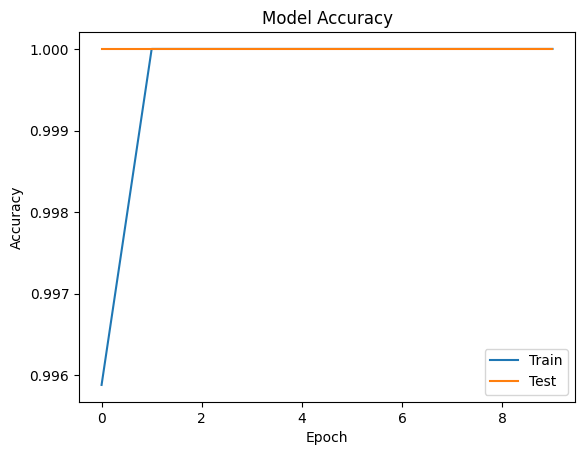

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])
plt.show()